# Stage 3 — Dynamic Carry & Risk Management

Completes plan §9: an explicit **static vs vol-targeted vs risk-managed** comparison, every
variant **gross and net of costs**, both universes, on the common window
**2007-05-01 → 2026-06-30**. Output: `outputs/stage3_dynamic_comparison.csv`.

| variant | book | exposure rule |
|---|---|---|
| `static` | unit gross (1/side) | none |
| `voltgt` | 10% vol target | none |
| `vix` | vol target | halve when VIX is above its trailing-3y 80th percentile |
| `ivrr` | vol target | halve when aggregate 1M ATM IV **or** 25Δ RR is above its trailing-3y 80th percentile (min of the two scalars) |
| `ivrr_lin` | vol target | same indicators, linear ramp 1.0 → 0.5 across the 80th–100th percentile |
| `rrccy` | vol target | per-currency: each **long** position scaled by that currency's own RR percentile |

All rules use `fx_utils.exposure_scalar` (trailing 756-day percentile rank, sampled at
month-end, effective the next trading day — the library's no-lookahead convention). Hedges are
applied to **weights**, so `roundtrip_cost` prices the reduced notional and the toggle trades —
this is what makes net-of-cost hedged tracks possible (the old backtest §5 hedge scaled the
return series and was therefore gross-only).

## §0 Setup — data, universes, indicators

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

import fx_utils as fx

OUT = Path('outputs')

g10_px = fx.load_wide('g10_fx_spot_forward')
em_px = fx.load_wide('em_fx_spot_forward')
spots = fx.spots_usd_per_fx(g10_px, em_px)
carry = fx.carry_panel(g10_px, em_px, tenor='1M')
xret = fx.excess_returns(spots, carry)

UNIVERSE_G10 = ['AUD', 'CAD', 'CHF', 'EUR', 'GBP', 'JPY', 'NOK', 'NZD', 'SEK']
UNIVERSE_ALL = [c for c in xret.columns if c not in ('HKD', 'DKK', 'CNY')]
VOL_TARGET = 0.10
WINDOW = slice('2007-05-01', '2026-06-30')

# conditioning indicators
vix = fx.load_wide('global_risk')['VIX'].dropna()
iv = fx.vol_surface_panel('ATM', '1M')
rr = fx.vol_surface_panel('RR', '1M', delta=25)

iv_g10 = iv[UNIVERSE_G10].mean(axis=1).rename('IV_G10')
rr_g10 = rr[UNIVERSE_G10].mean(axis=1).rename('RR_G10')
cov_all = [c for c in UNIVERSE_ALL if c in iv.columns]
iv_all = iv[cov_all].mean(axis=1).rename('IV_ALL')
rr_all = rr[cov_all].mean(axis=1).rename('RR_ALL')

bmk = fx.benchmark_returns()
hs_out, hs_pts = fx.forward_halfspreads('1M')

print(f'sample {xret.index[0].date()} -> {xret.index[-1].date()} | '
      f'{len(UNIVERSE_G10)} G10 / {len(UNIVERSE_ALL)} combined names | '
      f'option coverage {len(cov_all)}/{len(UNIVERSE_ALL)}')

sample 2007-01-01 -> 2026-06-30 | 9 G10 / 27 combined names | option coverage 21/27


## §1 Baselines — static unit-gross and vol-targeted

Same construction as `strategy_backtest.ipynb` §1–2: G10 tercile sort (9 names), combined
quintile sort (27 names), inverse-60d-vol legs, 40% leg cap, monthly rebalance effective next
day. `static` is the unit book (gross 1/side) *without* vol targeting — the row the plan noted
was never reported.

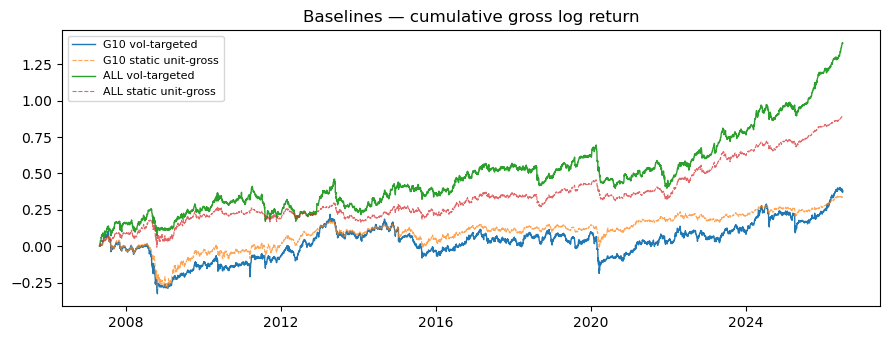

In [2]:
weights = {}
for uni, n_buckets in (('G10', 3), ('ALL', 5)):
    universe = UNIVERSE_G10 if uni == 'G10' else UNIVERSE_ALL
    w_unit = fx.carry_portfolio(carry, xret, n_buckets=n_buckets, universe=universe)
    weights[f'{uni}_static'] = w_unit
    weights[f'{uni}_voltgt'] = fx.vol_target_weights(w_unit, xret, target=VOL_TARGET)

fig, ax = plt.subplots(figsize=(9, 3.5))
for uni in ('G10', 'ALL'):
    ax.plot(fx.portfolio_returns(weights[f'{uni}_voltgt'], xret).loc[WINDOW].cumsum(),
            lw=1.0, label=f'{uni} vol-targeted')
    ax.plot(fx.portfolio_returns(weights[f'{uni}_static'], xret).loc[WINDOW].cumsum(),
            lw=0.8, ls='--', alpha=0.7, label=f'{uni} static unit-gross')
ax.legend(fontsize=8)
ax.set_title('Baselines — cumulative gross log return')
plt.tight_layout()
plt.show()

## §2 Exposure scalars — construction and diagnostics

`exposure_scalar` replaces the ad-hoc `hedge_scalar` of backtest §5. Windowing changed from a
36-month rolling quantile of month-end levels to a 756-trading-day percentile rank of the daily
level sampled at month-end (~ the same 3 years, but the quantile now uses ~756 observations
instead of 36) — agreement with the old rule is checked below.

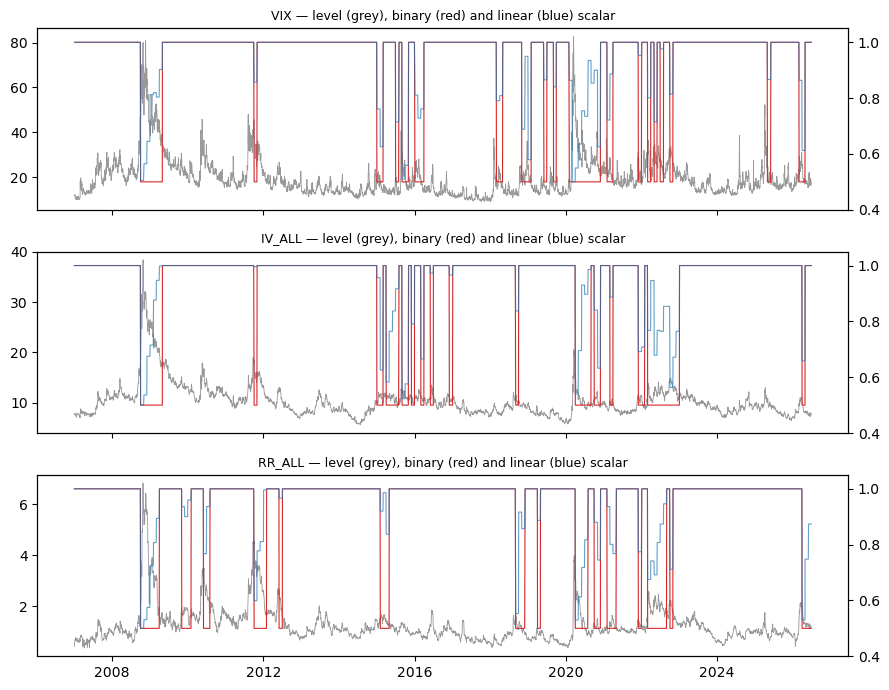

In [3]:
s_vix = fx.exposure_scalar(vix)
s_vix_lin = fx.exposure_scalar(vix, method='linear')
s_iv = {'G10': fx.exposure_scalar(iv_g10), 'ALL': fx.exposure_scalar(iv_all)}
s_rr = {'G10': fx.exposure_scalar(rr_g10), 'ALL': fx.exposure_scalar(rr_all)}
s_iv_lin = {'G10': fx.exposure_scalar(iv_g10, method='linear'),
            'ALL': fx.exposure_scalar(iv_all, method='linear')}
s_rr_lin = {'G10': fx.exposure_scalar(rr_g10, method='linear'),
            'ALL': fx.exposure_scalar(rr_all, method='linear')}

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, (name, ind, s_b, s_l) in zip(axes, [('VIX', vix, s_vix, s_vix_lin),
                                            ('IV_ALL', iv_all, s_iv['ALL'], s_iv_lin['ALL']),
                                            ('RR_ALL', rr_all, s_rr['ALL'], s_rr_lin['ALL'])]):
    ax.plot(ind, color='0.6', lw=0.6)
    ax2 = ax.twinx()
    ax2.plot(s_b, color='C3', lw=0.8)
    ax2.plot(s_l, color='C0', lw=0.8, alpha=0.7)
    ax2.set_ylim(0.4, 1.05)
    ax.set_title(f'{name} — level (grey), binary (red) and linear (blue) scalar', fontsize=9)
plt.tight_layout()
plt.show()

In [4]:
# no lookahead: recomputing on data truncated at mid-sample reproduces the scalar through T
T = vix.index[len(vix) // 2]
pd.testing.assert_series_equal(s_vix.loc[:T], fx.exposure_scalar(vix.loc[:T]))
print(f'no-lookahead check passed (truncation at {T.date()})')

# de-risked month fraction post burn-in (expect ~1-q = 0.20)
for name, s in (('VIX', s_vix), ('IV_ALL', s_iv['ALL']), ('RR_ALL', s_rr['ALL'])):
    me = s.resample('ME').last().iloc[40:]
    print(f'{name}: {(me < 1.0).mean():.2f} of months de-risked')

# monthly decision agreement with the old ad-hoc rule (36m rolling quantile of month-ends)
def hedge_scalar_old(level, q=0.80, window=36, min_periods=24, scale=0.5):
    me = level.resample('ME').last()
    trigger = me > me.rolling(window, min_periods=min_periods).quantile(q)
    return trigger.map({True: scale, False: 1.0})

for name, ind in (('IV_ALL', iv_all), ('RR_ALL', rr_all)):
    pct_me = ind.rolling(756, min_periods=378).rank(pct=True).resample('ME').last()
    new_dec = pd.Series(np.where(pct_me > 0.80, 0.5, 1.0), index=pct_me.index)
    old_dec = hedge_scalar_old(ind)
    both = pd.concat([new_dec.rename('new'), old_dec.rename('old')], axis=1).iloc[40:].dropna()
    print(f'{name}: monthly decision agreement with old 36m rule '
          f'{(both.new == both.old).mean():.2f}')

no-lookahead check passed (truncation at 2016-10-19)
VIX: 0.19 of months de-risked
IV_ALL: 0.18 of months de-risked
RR_ALL: 0.18 of months de-risked
IV_ALL: monthly decision agreement with old 36m rule 0.97
RR_ALL: monthly decision agreement with old 36m rule 0.97


## §3 Book-level hedges — VIX, IV/RR (binary), IV/RR (linear)

Scalars multiply the **vol-targeted weight panel** (docstring recipe), so the cost model sees
the reduced notional. IV and RR scalars combine via `min` — either indicator breaching its 80th
percentile de-risks the book, as in backtest §5.

In [5]:
def apply_scalar(w, s):
    return w.mul(s.reindex(w.index, method='ffill').fillna(1.0), axis=0)

for uni in ('G10', 'ALL'):
    w_vt = weights[f'{uni}_voltgt']
    weights[f'{uni}_vix'] = apply_scalar(w_vt, s_vix)
    weights[f'{uni}_ivrr'] = apply_scalar(
        w_vt, pd.concat([s_iv[uni], s_rr[uni]], axis=1).min(axis=1))
    weights[f'{uni}_ivrr_lin'] = apply_scalar(
        w_vt, pd.concat([s_iv_lin[uni], s_rr_lin[uni]], axis=1).min(axis=1))

# machinery check: weights-level scaling == return-level scaling, gross
for uni in ('G10', 'ALL'):
    s = pd.concat([s_iv[uni], s_rr[uni]], axis=1).min(axis=1)
    ret_w = fx.portfolio_returns(weights[f'{uni}_ivrr'], xret)
    vt_gross = fx.portfolio_returns(weights[f'{uni}_voltgt'], xret)
    ret_r = vt_gross * s.reindex(xret.index, method='ffill').fillna(1.0)
    assert (ret_w - ret_r).abs().max() < 1e-12
    # continuity with the old backtest §5 hedged track (windowing 36m -> 756d)
    iv_a, rr_a = (iv_g10, rr_g10) if uni == 'G10' else (iv_all, rr_all)
    s_old = pd.concat([hedge_scalar_old(iv_a), hedge_scalar_old(rr_a)], axis=1).min(axis=1)
    old_track = vt_gross * s_old.reindex(vt_gross.index, method='ffill').shift(1)
    c = pd.concat([ret_w.rename('new'), old_track.rename('old')], axis=1).dropna().corr().iloc[0, 1]
    print(f'{uni}: corr(new ivrr, old backtest §5 hedge) = {c:.4f}')

# cost-model alignment: book-level hedged panels must trade on <= 2 days per month
for key in [k for k in weights if ('vix' in k) or ('ivrr' in k)]:
    chg = (weights[key].fillna(0).diff().abs().sum(axis=1) > 1e-12).resample('ME').sum()
    chg = chg.loc['2007-06':]
    print(f'{key}: max change-days/month {int(chg.max())}, '
          f'share of 2-day months {(chg == 2).mean():.2f}')
    assert chg.max() <= 2, key

G10: corr(new ivrr, old backtest §5 hedge) = 0.9906
ALL: corr(new ivrr, old backtest §5 hedge) = 0.9915
G10_vix: max change-days/month 2, share of 2-day months 0.02
G10_ivrr: max change-days/month 1, share of 2-day months 0.00
G10_ivrr_lin: max change-days/month 2, share of 2-day months 0.00
ALL_vix: max change-days/month 2, share of 2-day months 0.02
ALL_ivrr: max change-days/month 2, share of 2-day months 0.00
ALL_ivrr_lin: max change-days/month 2, share of 2-day months 0.00


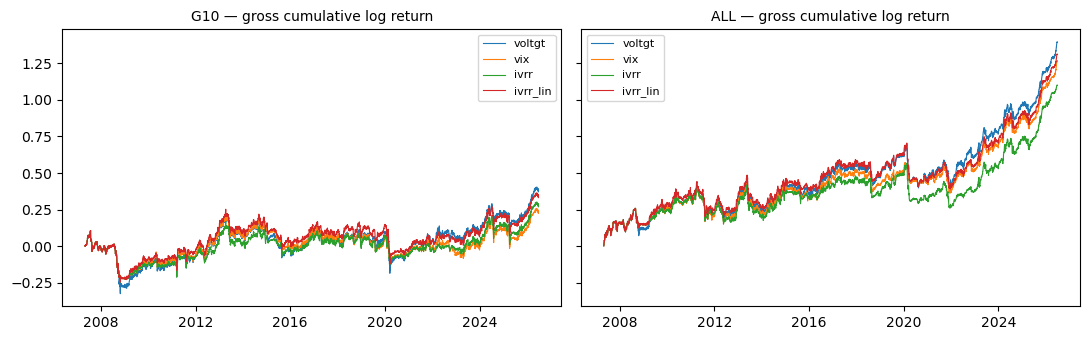

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, uni in zip(axes, ('G10', 'ALL')):
    for var in ('voltgt', 'vix', 'ivrr', 'ivrr_lin'):
        r = fx.portfolio_returns(weights[f'{uni}_{var}'], xret).loc[WINDOW]
        ax.plot(r.cumsum(), lw=0.8, label=var)
    ax.set_title(f'{uni} — gross cumulative log return', fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## §4 Per-currency RR conditioning

Each currency's **long** weight is scaled by its own RR percentile scalar. Longs only: RR is
sign-normalised crash-positive *for a long-FX position*; a funding short's crash risk is the
opposite tail, so scaling shorts on the same signal would be wrong-signed. The resulting net
long-USD tilt in stress months is the intended crash hedge (USD rallies in crises); the book's
net exposure is reported below. Currencies without option surfaces (CLP COP IDR MYR PEN PHP)
keep scalar 1.0. No re-vol-targeting afterwards — lower realised vol in de-risked months *is*
the hedge.

ALL_rrccy: net FX exposure min -1.10 / mean -0.102; max change-days/month 3


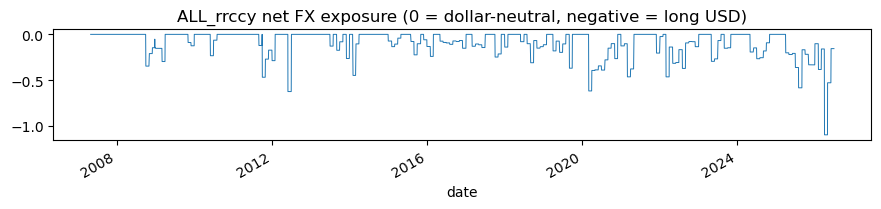

In [7]:
S_ccy = pd.DataFrame({c: fx.exposure_scalar(rr[c].dropna()) for c in rr.columns})
for uni in ('G10', 'ALL'):
    w_vt = weights[f'{uni}_voltgt']
    S_al = (S_ccy.reindex(w_vt.index, method='ffill')
                 .reindex(columns=w_vt.columns).fillna(1.0))
    weights[f'{uni}_rrccy'] = w_vt.where(w_vt <= 0, w_vt * S_al)

net_exp = weights['ALL_rrccy'].sum(axis=1).loc[WINDOW]
trade_days = ((weights['ALL_rrccy'].fillna(0).diff().abs().sum(axis=1) > 1e-12)
              .resample('ME').sum().loc['2007-06':])
print(f'ALL_rrccy: net FX exposure min {net_exp.min():.2f} / mean {net_exp.mean():.3f}; '
      f'max change-days/month {int(trade_days.max())}')
net_exp.plot(figsize=(9, 2.2), lw=0.7,
             title='ALL_rrccy net FX exposure (0 = dollar-neutral, negative = long USD)')
plt.tight_layout()
plt.show()

## §5 Statistics — all variants, gross and net, common window

Every variant runs through the same cost machinery (`roundtrip_cost`: changed notional pays the
outright half-spread, maintained notional rolls at the points half-spread). Alpha of each
dynamic rule on its baseline (hedges on `voltgt`, `voltgt` on `static`; same cost basis) via
Newey–West, 5 lags — the regression is scale-invariant, unlike a raw return difference.

In [8]:
VARIANTS = ['static', 'voltgt', 'vix', 'ivrr', 'ivrr_lin', 'rrccy']
tracks, costs = {}, {}
for uni in ('G10', 'ALL'):
    for var in VARIANTS:
        key = f'{uni}_{var}'
        w = weights[key]
        gross = fx.portfolio_returns(w, xret, f'{key}_gross')
        cost = fx.roundtrip_cost(w, hs_out, hs_pts)
        tracks[f'{key}_gross'] = gross
        tracks[f'{key}_net'] = (gross - cost).rename(f'{key}_net')
        costs[key] = cost

daily = pd.concat(tracks.values(), axis=1).loc[WINDOW]
bmk_w = bmk[['DBHVG10U', 'FXCTEM8']].loc[WINDOW]

g10_cols = [c for c in daily.columns if c.startswith('G10')]
all_cols = [c for c in daily.columns if c.startswith('ALL')]
summary = pd.concat([
    fx.summary_stats(daily[g10_cols], benchmark=bmk['DBHVG10U']),
    fx.summary_stats(daily[all_cols], benchmark=bmk['FXCTEM8']),
    fx.summary_stats(bmk_w),
])

BASE = {'static': None, 'voltgt': 'static', 'vix': 'voltgt',
        'ivrr': 'voltgt', 'ivrr_lin': 'voltgt', 'rrccy': 'voltgt'}
extras = {}
for uni in ('G10', 'ALL'):
    for var in VARIANTS:
        key = f'{uni}_{var}'
        to = fx.turnover(weights[key].loc[WINDOW])
        for basis in ('gross', 'net'):
            row = f'{key}_{basis}'
            e = {'avg_monthly_turnover': to}
            if basis == 'net':
                live = daily[row].dropna().index
                e['ann_cost_drag'] = float(costs[key].reindex(live).mean() * fx.ANN_DAYS)
            if BASE[var] is not None:
                base_row = f'{uni}_{BASE[var]}_{basis}'
                res = fx.nw_regression(
                    daily[row], daily[[base_row]].rename(columns={base_row: 'base'}), lags=5)
                if res is not None:
                    e['base'] = base_row
                    e['alpha_vs_base_ann'] = res['alpha_ann']
                    e['t_alpha_vs_base'] = res['alpha_t']
            extras[row] = e
summary = summary.join(pd.DataFrame(extras).T)

order = ([f'{u}_{v}_{b}' for u in ('G10', 'ALL') for v in VARIANTS for b in ('gross', 'net')]
         + ['DBHVG10U', 'FXCTEM8'])
summary = summary.loc[order]
show = ['ann_return', 'ann_vol', 'sharpe', 'sortino', 'calmar', 'max_drawdown', 'CVaR_99',
        'skew', 'info_ratio', 'avg_monthly_turnover', 'ann_cost_drag',
        'alpha_vs_base_ann', 't_alpha_vs_base']
summary[show].astype(float).round(3)

,ann_return,ann_vol,sharpe,sortino,calmar,max_drawdown,CVaR_99,skew,info_ratio,avg_monthly_turnover,ann_cost_drag,alpha_vs_base_ann,t_alpha_vs_base
G10_static_gross,0.017,0.090,0.189,0.255,0.041,-0.317,0.025,-0.735,0.338,0.167,NaN,NaN,NaN
G10_static_net,0.014,0.090,0.160,0.216,0.033,-0.320,0.025,-0.735,0.303,0.167,0.003,NaN,NaN
G10_voltgt_gross,0.019,0.115,0.167,0.222,0.035,-0.365,0.032,-0.954,0.269,0.377,NaN,-0.001,-0.051
G10_voltgt_net,0.014,0.115,0.119,0.159,0.019,-0.382,0.032,-0.952,0.214,0.377,0.006,-0.003,-0.287
G10_vix_gross,0.012,0.104,0.114,0.153,0.021,-0.316,0.027,-0.671,0.205,0.433,NaN,-0.005,-0.856
G10_vix_net,0.005,0.104,0.052,0.069,-0.000,-0.349,0.027,-0.668,0.138,0.433,0.006,-0.007,-1.154
G10_ivrr_gross,0.014,0.099,0.142,0.191,0.030,-0.306,0.026,-0.678,0.230,0.409,NaN,-0.002,-0.302
G10_ivrr_net,0.008,0.099,0.080,0.108,0.010,-0.310,0.026,-0.675,0.165,0.409,0.006,-0.003,-0.564
G10_ivrr_lin_gross,0.017,0.106,0.163,0.217,0.034,-0.342,0.029,-0.844,0.256,0.381,NaN,-0.000,-0.046
G10_ivrr_lin_net,0.012,0.106,0.109,0.145,0.016,-0.362,0.029,-0.842,0.197,0.381,0.006,-0.001,-0.238


In [9]:
# robustness: direct NW t-stat on the mean of (dynamic - base), HAC 5 lags.
# Forces beta = 1, unlike the alpha regression above; shown for reference only.
rows = {}
for row_name, e in extras.items():
    if 'base' not in e:
        continue
    d = (daily[row_name] - daily[e['base']]).dropna()
    res = sm.OLS(d.values, np.ones(len(d))).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    rows[row_name] = {'mean_diff_ann': float(res.params[0]) * fx.ANN_DAYS,
                      't_diff': float(res.tvalues[0])}
pd.DataFrame(rows).T.round(3)

,mean_diff_ann,t_diff
G10_voltgt_gross,0.002,0.204
G10_voltgt_net,-0.001,-0.058
G10_vix_gross,-0.007,-1.157
G10_vix_net,-0.008,-1.303
G10_ivrr_gross,-0.005,-0.729
G10_ivrr_net,-0.006,-0.815
G10_ivrr_lin_gross,-0.002,-0.451
G10_ivrr_lin_net,-0.002,-0.503
G10_rrccy_gross,-0.001,-0.128
G10_rrccy_net,-0.001,-0.182


## §6 Output — `outputs/stage3_dynamic_comparison.csv`

In [10]:
summary.to_csv(OUT / 'stage3_dynamic_comparison.csv')

# acceptance criteria (plan §9)
strat = summary.drop(['DBHVG10U', 'FXCTEM8'])
assert len(summary) == 26
starts, ends = strat['start'].astype(str), strat['end'].astype(str)
assert (starts >= '2007-05-01').all() and (starts <= '2007-05-02').all(), sorted(starts.unique())
assert (ends == '2026-06-30').all(), sorted(ends.unique())
dyn = strat[strat['base'].notna()]
assert len(dyn) == 20 and dyn['t_alpha_vs_base'].notna().all()
print('stage3_dynamic_comparison.csv written', summary.shape)
print('benchmark rows span:', summary.loc['DBHVG10U', 'start'], '->',
      summary.loc['DBHVG10U', 'end'], '/', summary.loc['FXCTEM8', 'start'], '->',
      summary.loc['FXCTEM8', 'end'])

stage3_dynamic_comparison.csv written (26, 27)
benchmark rows span: 2007-05-01 -> 2026-06-30 / 2007-05-01 -> 2026-06-30


## §7 Verdicts

Framework (plan §9 acceptance criteria): **adopt** if the rule's net-of-cost alpha on its
baseline is significant (t ≳ 2); **tail-insurance-only** if alpha is insignificant or negative
but CVaR₉₉ / skew / MaxDD improve materially; **reject** otherwise. All numbers are **net**,
common window 2007-05 → 2026-06. Hedged rules are judged against `voltgt`; `voltgt` against
`static` (the alpha regression is scale-invariant, so the static book's lower running vol —
9.0% G10 / 7.6% ALL — doesn't distort the comparison).

| rule | G10 | ALL (combined) |
|---|---|---|
| vol targeting | adopt as sizing standard | adopt as sizing standard |
| VIX threshold | tail-insurance-only | tail-insurance-only |
| IV/RR binary | tail-insurance-only | **reject** |
| IV/RR linear | tail-insurance-only | reject |
| per-currency RR | tail-insurance-only — preferred | tail-insurance-only — **preferred** |

- **Vol targeting — adopt as the sizing standard, with no alpha claim.** ALL: net alpha on
  static +0.5%/yr (t = 0.51), Sharpe 0.455 → 0.466 — it scales the book to the 10% mandate and
  roughly preserves risk-adjusted return. G10: −0.3%/yr (t = −0.29), Sharpe 0.160 → 0.119 — the
  extra turnover (0.17 → 0.38/month) is pure cost in the low-Sharpe majors. Keep it because the
  mandate and every cross-variant comparison need a common vol scale, not because it adds alpha.
- **VIX threshold — tail insurance.** G10: t = −1.15, Sharpe 0.119 → 0.052, but CVaR₉₉
  3.2% → 2.7%, skew −0.95 → −0.67, MaxDD −38% → −35% — material tail relief at a heavy Sharpe
  price. ALL: t = −0.27, Sharpe 0.466 → 0.441, MaxDD −29% → −25%, CVaR₉₉ 2.9% → 2.7% — cheap
  insurance for the combined book, and notably better than the FX-implied-vol version of the
  same rule.
- **IV/RR binary (the original backtest §5 rule, now net of costs) — reject for the combined
  book.** ALL: t = −1.69 (the closest thing to a significant result in the table, and it is
  *negative*), Sharpe 0.466 → 0.369, while MaxDD *worsens* (−29% → −31%) and skew *worsens*
  (−0.65 → −0.73): net of costs it fails its own tail-insurance purpose. G10: t = −0.56 with
  real tail relief (CVaR₉₉ 3.2% → 2.6%, MaxDD −38% → −31%, skew −0.95 → −0.68) —
  tail-insurance-only there.
- **IV/RR linear — dominated.** It softens the binary rule's Sharpe cost (ALL 0.450 vs 0.369;
  G10 0.109 vs 0.080) but delivers correspondingly little tail improvement (ALL MaxDD −31%,
  still worse than unhedged). Strictly between `voltgt` and the binary rule on every metric:
  no reason to hold it over the VIX or per-currency alternatives.
- **Per-currency RR — the best hedge in the table.** Essentially free (G10 t = 0.01, Sharpe
  0.116 vs 0.119; ALL t = −0.04, Sharpe 0.457 vs 0.466) while still improving the tail: ALL
  MaxDD −29% → −28%, CVaR₉₉ 2.9% → 2.7%, and the best skew of any combined variant
  (−0.65 → −0.60); G10 MaxDD −38% → −34%. Caveat: scaling longs only breaks dollar-neutrality
  by design (mean net FX exposure −0.10, briefly −1.1 in 2008-style stress) — the long-USD
  tilt in crises *is* the hedge, but it must be reported as an exposure, not hidden.

**Stage-3 takeaway.** No exposure-timing rule adds statistically significant net alpha —
consistent with Stage 2's finding that carry compensates priced crash risk: selling exposure
when risk indicators are elevated gives back premium roughly one-for-one. What risk management
*can* do is reshape the tail at near-zero cost, and the refinements matter: the original
book-level binary IV/RR hedge (Sharpe 0.63 → 0.53 gross) is actually rejected once costs are
counted, while the per-currency RR rule achieves the tail improvement for ~1 Sharpe point.
**Bar for Stage 6:** a regime rule must beat per-currency RR (ALL net Sharpe 0.457, MaxDD −28%,
skew −0.60) and the VIX threshold (0.441, −25%) — not the old binary hedge.
